In [2]:
import os
import json
import tiktoken
import numpy as np
import pandas as pd
from scipy.stats import levene
import matplotlib.pyplot as plt

In [3]:
def format_indexed_inputs(name_list):
    return json.dumps(
        [f"{i}: {name}" for i, name in enumerate(name_list)],
        ensure_ascii=False
    )

#### Mean accuracy and std for base model


In [4]:
base_t03_p01 = pd.read_csv(os.path.join(os.getcwd(), "results", "base model results", "temp_0.3_p_0.1.csv"))
base_t03_p03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base model results", "temp_0.3_p_0.3.csv"))
base_t0_p01 = pd.read_csv(os.path.join(os.getcwd(), "results", "base model results", "temp_0_p_0.1.csv"))
base_t0_p03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base model results", "temp_0_p_0.3.csv"))

In [5]:
common_cols = (
    base_t03_p01.columns
    .intersection(base_t03_p03.columns)
    .intersection(base_t0_p01.columns)
    .intersection(base_t0_p03.columns)
)

summary_df = pd.DataFrame({"column": common_cols})

dfs = {
    "base_t0_p01": base_t0_p01,
    "base_t0_p03": base_t0_p03,
    "base_t03_p01": base_t03_p01,
    "base_t03_p03": base_t03_p03,    
}

for name, df in dfs.items():
    summary_df[f"{name}_mean"] = df[common_cols].mean().reindex(common_cols).values.round(3)
    summary_df[f"{name}_std"] = df[common_cols].std(ddof=1).reindex(common_cols).values.round(3)

display(summary_df)


,column,base_t0_p01_mean,base_t0_p01_std,base_t0_p03_mean,base_t0_p03_std,base_t03_p01_mean,base_t03_p01_std,base_t03_p03_mean,base_t03_p03_std
0,abbreviation,16.3,0.949,22.1,1.370,22.0,0.816,22.7,0.483
1,brand_parent,60.5,2.991,66.8,7.421,64.5,3.100,68.2,5.007
2,legal_suffix,52.2,0.919,52.8,1.751,52.8,1.229,53.6,1.075
3,partial,67.9,2.885,76.0,8.300,71.0,4.967,78.8,5.391
4,punctuation,331.9,8.306,422.8,40.581,400.9,19.244,423.2,34.743
5,typography,634.5,18.537,882.4,77.987,839.4,39.033,881.0,62.505


In [6]:
# read test data
test_data = pd.read_csv(os.path.join(os.getcwd(), "selected_data.csv"))
new_df = test_data.groupby("type").size() 
display(new_df)

type
abbreviation     124
brand_parent     196
legal_suffix     116
partial          303
punctuation      760
typography      1501
dtype: int64

In [24]:
display(base_t0_p01.T.reset_index().rename(columns={"index": "column"}))

,column,0,1,2,3,4,5,6,7,8,9
0,abbreviation,17,16,15,16,16,15,17,16,17,18
1,brand_parent,56,61,64,61,59,64,60,64,56,60
2,legal_suffix,52,51,51,52,53,52,52,54,52,53
3,partial,65,70,72,71,68,70,64,67,64,68
4,punctuation,323,331,326,339,327,344,342,339,326,322
5,typography,613,626,635,657,619,652,649,660,613,621


#### Hypothesis testing

In [7]:
# Divide numeric columns in summary_df by the corresponding row count from new_df
base_t0_p01_div = base_t0_p01.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t0_p01_div.select_dtypes(include="number").columns
denominator = base_t0_p01_div["column"].map(new_df)
base_t0_p01_div[numeric_cols] = base_t0_p01_div[numeric_cols].div(denominator, axis=0).round(3)
base_t0_p01_div = base_t0_p01_div.set_index("column").T

base_t0_p03_div = base_t0_p03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t0_p03_div.select_dtypes(include="number").columns
denominator = base_t0_p03_div["column"].map(new_df)
base_t0_p03_div[numeric_cols] = base_t0_p03_div[numeric_cols].div(denominator, axis=0).round(3)
base_t0_p03_div = base_t0_p03_div.set_index("column").T

base_t03_p01_div = base_t03_p01.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t03_p01_div.select_dtypes(include="number").columns
denominator = base_t03_p01_div["column"].map(new_df)
base_t03_p01_div[numeric_cols] = base_t03_p01_div[numeric_cols].div(denominator, axis=0).round(3)
base_t03_p01_div = base_t03_p01_div.set_index("column").T

base_t03_p03_div = base_t03_p03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t03_p03_div.select_dtypes(include="number").columns
denominator = base_t03_p03_div["column"].map(new_df)
base_t03_p03_div[numeric_cols] = base_t03_p03_div[numeric_cols].div(denominator, axis=0).round(3)
base_t03_p03_div = base_t03_p03_div.set_index("column").T


In [8]:
# test if temperature changes std
common_cols = base_t0_p01_div.columns.intersection(base_t03_p01_div.columns)

results = []
for col in common_cols:
    x = base_t0_p01_div[col].dropna()
    y = base_t03_p01_div[col].dropna()

    stat, p_value = levene(x, y, center='median')
    p_one_sided = p_value / 2 if np.var(x, ddof=1) < np.var(y, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "std_t0_p01": x.std(ddof=1),
        "std_t03_p01": y.std(ddof=1),        
        "p_one_sided": p_one_sided,
        "p <= 0.05": p_one_sided < 0.05
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

results = []
for col in common_cols:
    x = base_t0_p03_div[col].dropna()
    y = base_t03_p03_div[col].dropna()

    stat, p_value = levene(x, y, center='median')
    p_one_sided = p_value / 2 if np.var(x, ddof=1) < np.var(y, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "std_t0_p03": x.std(ddof=1),
        "std_t03_p03": y.std(ddof=1),        
        "p_one_sided": p_one_sided,
        "p <= 0.05": p_one_sided < 0.05
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

         column  std_t0_p01  std_t03_p01  p_one_sided  p <= 0.05
0  abbreviation       0.008        0.007        0.643      False
1  brand_parent       0.015        0.016        0.500      False
2  legal_suffix       0.008        0.011        0.102      False
3       partial       0.010        0.016        0.165      False
4   punctuation       0.011        0.025        0.084      False
5    typography       0.012        0.026        0.150      False
         column  std_t0_p03  std_t03_p03  p_one_sided  p <= 0.05
0  abbreviation       0.011        0.004        0.991      False
1  brand_parent       0.038        0.026        0.853      False
2  legal_suffix       0.015        0.009        0.935      False
3       partial       0.027        0.018        0.843      False
4   punctuation       0.053        0.046        0.680      False
5    typography       0.052        0.042        0.708      False


In [9]:
# test if top p changes std
results = []
for col in common_cols:
    x = base_t0_p01_div[col].dropna()
    y = base_t0_p03_div[col].dropna()

    stat, p_value = levene(x, y, center='median')
    p_one_sided = p_value / 2 if np.var(x, ddof=1) < np.var(y, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "std_t0_p01": x.std(ddof=1),
        "std_t0_p03": y.std(ddof=1),        
        "p_one_sided": p_one_sided,
        "p <= 0.05": p_one_sided < 0.05
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

results = []
for col in common_cols:
    x = base_t03_p01_div[col].dropna()
    y = base_t03_p03_div[col].dropna()

    stat, p_value = levene(x, y, center='median')
    p_one_sided = p_value / 2 if np.var(x, ddof=1) < np.var(y, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "std_t03_p01": x.std(ddof=1),
        "std_t03_p03": y.std(ddof=1),        
        "p_one_sided": p_one_sided,
        "p <= 0.05": p_one_sided < 0.05
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

         column  std_t0_p01  std_t0_p03  p_one_sided  p <= 0.05
0  abbreviation       0.008       0.011        0.123      False
1  brand_parent       0.015       0.038        0.023       True
2  legal_suffix       0.008       0.015        0.024       True
3       partial       0.010       0.027        0.017       True
4   punctuation       0.011       0.053        0.008       True
5    typography       0.012       0.052        0.014       True
         column  std_t03_p01  std_t03_p03  p_one_sided  p <= 0.05
0  abbreviation        0.007        0.004        0.902      False
1  brand_parent        0.016        0.026        0.176      False
2  legal_suffix        0.011        0.009        0.735      False
3       partial        0.016        0.018        0.354      False
4   punctuation        0.025        0.046        0.115      False
5    typography        0.026        0.042        0.138      False


#### Canonicalization

In [54]:
base_t0 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.csv"))
base_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.3.csv"))
canonical_t0 = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.csv"))
canonical_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.3.csv"))
sample_data = pd.read_csv(os.path.join(os.getcwd(), "selected_data2.csv"))
group_df = sample_data.groupby("type").size() 

In [ ]:
base_t0_div = base_t0.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t0_div.select_dtypes(include="number").columns
denominator = base_t0_div["column"].map(group_df)
base_t0_div[numeric_cols] = base_t0_div[numeric_cols].div(denominator, axis=0).round(3)
base_t0_div = base_t0_div.set_index("column").T

base_t03_div = base_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t03_div.select_dtypes(include="number").columns
denominator = base_t03_div["column"].map(group_df)
base_t03_div[numeric_cols] = base_t03_div[numeric_cols].div(denominator, axis=0).round(3)
base_t03_div = base_t03_div.set_index("column").T

canonical_t0_div = canonical_t0.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = canonical_t0_div.select_dtypes(include="number").columns
denominator = canonical_t0_div["column"].map(group_df)
canonical_t0_div[numeric_cols] = canonical_t0_div[numeric_cols].div(denominator, axis=0).round(3)
canonical_t0_div = canonical_t0_div.set_index("column").T

canonical_t03_div = canonical_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = canonical_t03_div.select_dtypes(include="number").columns
denominator = canonical_t03_div["column"].map(group_df)
canonical_t03_div[numeric_cols] = canonical_t03_div[numeric_cols].div(denominator, axis=0).round(3)
canonical_t03_div = canonical_t03_div.set_index("column").T

In [76]:
results = []
for col in common_cols:
    x = canonical_t0_div[col].dropna()
    y = base_t0_div[col].dropna()

    stat, p_value = levene(x, y, center='median')
    p_one_sided = p_value / 2 if np.var(x, ddof=1) < np.var(y, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "base_model_t0": y.std(ddof=1),
        "canonical_t0": x.std(ddof=1),
        "p_one_sided": p_one_sided,
        "p <= 0.05": p_one_sided < 0.05
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

results = []
for col in common_cols:
    x = canonical_t03_div[col].dropna()
    y = base_t03_div[col].dropna()

    stat, p_value = levene(x, y, center='median')
    p_one_sided = p_value / 2 if np.var(x, ddof=1) < np.var(y, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "base_model_t03": y.std(ddof=1),
        "canonical_t03": x.std(ddof=1),
        "p_one_sided": p_one_sided,
        "p <= 0.05": p_one_sided < 0.05
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

         column  base_model_t0  canonical_t0  p_one_sided  p <= 0.05
0  abbreviation          0.006         0.032        0.998      False
1  brand_parent          0.013         0.074        0.994      False
2  legal_suffix          0.012         0.069        0.999      False
3       partial          0.006         0.063        0.998      False
4   punctuation          0.004         0.084        0.999      False
5    typography          0.006         0.077        0.997      False
         column  base_model_t03  canonical_t03  p_one_sided  p <= 0.05
0  abbreviation           0.013          0.027        0.980      False
1  brand_parent           0.033          0.059        0.926      False
2  legal_suffix           0.009          0.059        0.983      False
3       partial           0.031          0.048        0.941      False
4   punctuation           0.008          0.047        0.998      False
5    typography           0.011          0.048        1.000      False


#### Ensemble Method

In [67]:
base_t0 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.csv"))
base_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.3.csv"))
ensemble_3_t0 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.csv"))
ensemble_3_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.3.csv"))
ensemble_5_t0 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_5_t0.csv"))
ensemble_5_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_5_t0.3.csv"))
sample_data = pd.read_csv(os.path.join(os.getcwd(), "selected_data2.csv"))
group_df = sample_data.groupby("type").size() 

In [68]:
base_t0_div = base_t0.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t0_div.select_dtypes(include="number").columns
denominator = base_t0_div["column"].map(group_df)
base_t0_div[numeric_cols] = base_t0_div[numeric_cols].div(denominator, axis=0).round(3)
base_t0_div = base_t0_div.set_index("column").T

base_t03_div = base_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t03_div.select_dtypes(include="number").columns
denominator = base_t03_div["column"].map(group_df)
base_t03_div[numeric_cols] = base_t03_div[numeric_cols].div(denominator, axis=0).round(3)
base_t03_div = base_t03_div.set_index("column").T

ensemble_3_t0_div = ensemble_3_t0.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = ensemble_3_t0_div.select_dtypes(include="number").columns
denominator = ensemble_3_t0_div["column"].map(group_df)
ensemble_3_t0_div[numeric_cols] = ensemble_3_t0_div[numeric_cols].div(denominator, axis=0).round(3)
ensemble_3_t0_div = ensemble_3_t0_div.set_index("column").T

ensemble_3_t03_div = ensemble_3_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = ensemble_3_t03_div.select_dtypes(include="number").columns
denominator = ensemble_3_t03_div["column"].map(group_df)
ensemble_3_t03_div[numeric_cols] = ensemble_3_t03_div[numeric_cols].div(denominator, axis=0).round(3)
ensemble_3_t03_div = ensemble_3_t03_div.set_index("column").T

ensemble_5_t0_div = ensemble_5_t0.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = ensemble_5_t0_div.select_dtypes(include="number").columns
denominator = ensemble_5_t0_div["column"].map(group_df)
ensemble_5_t0_div[numeric_cols] = ensemble_5_t0_div[numeric_cols].div(denominator, axis=0).round(3)
ensemble_5_t0_div = ensemble_5_t0_div.set_index("column").T

ensemble_5_t03_div = ensemble_5_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = ensemble_5_t03_div.select_dtypes(include="number").columns
denominator = ensemble_5_t03_div["column"].map(group_df)
ensemble_5_t03_div[numeric_cols] = ensemble_5_t03_div[numeric_cols].div(denominator, axis=0).round(3)
ensemble_5_t03_div = ensemble_5_t03_div.set_index("column").T

In [72]:
results = []
for col in common_cols:
    x = base_t0_div[col].dropna()
    y1 = ensemble_3_t0_div[col].dropna()
    y2 = ensemble_5_t0_div[col].dropna()

    stat, p_value = levene(x, y1, center='median')
    p_one_sided1 = p_value / 2 if np.var(x, ddof=1) > np.var(y1, ddof=1) else 1 - (p_value / 2)
    stat, p_value = levene(x, y2, center='median')
    p_one_sided2 = p_value / 2 if np.var(x, ddof=1) > np.var(y2, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "base_model_t0": x.std(ddof=1),
        "ensemble_3_t0": y1.std(ddof=1),
        "ensemble_5_t0": y2.std(ddof=1),
        "p_one_sided1": p_one_sided1,
        "p_one_sided2": p_one_sided2,        
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

         column  base_model_t0  ensemble_3_t0  ensemble_5_t0  p_one_sided1  \
0  abbreviation          0.006          0.008          0.010         0.829   
1  brand_parent          0.013          0.003          0.005         0.012   
2  legal_suffix          0.012          0.009          0.009         0.344   
3       partial          0.006          0.006          0.004         0.393   
4   punctuation          0.004          0.002          0.001         0.010   
5    typography          0.006          0.003          0.003         0.001   

   p_one_sided2  
0         0.784  
1         0.044  
2         0.199  
3         0.080  
4         0.002  
5         0.004  


In [71]:
results = []
for col in common_cols:
    x = base_t03_div[col].dropna()
    y1 = ensemble_3_t03_div[col].dropna()
    y2 = ensemble_5_t03_div[col].dropna()

    stat, p_value = levene(x, y1, center='median')
    p_one_sided1 = p_value / 2 if np.var(x, ddof=1) > np.var(y1, ddof=1) else 1 - (p_value / 2)
    stat, p_value = levene(x, y2, center='median')
    p_one_sided2 = p_value / 2 if np.var(x, ddof=1) > np.var(y2, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "base_model_t03": x.std(ddof=1),
        "ensemble_3_t03": y1.std(ddof=1),
        "ensemble_5_t03": y2.std(ddof=1),
        "p_one_sided1": p_one_sided1,
        "p_one_sided2": p_one_sided2,        
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

         column  base_model_t03  ensemble_3_t03  ensemble_5_t03  p_one_sided1  \
0  abbreviation           0.013           0.005           0.006         0.221   
1  brand_parent           0.033           0.008           0.003         0.050   
2  legal_suffix           0.009           0.009           0.006         0.274   
3       partial           0.031           0.005           0.005         0.049   
4   punctuation           0.008           0.002           0.002         0.206   
5    typography           0.011           0.006           0.004         0.273   

   p_one_sided2  
0         0.221  
1         0.032  
2         0.000  
3         0.053  
4         0.206  
5         0.118  


#### Ensemble + Canonicalizatoin


In [73]:
base_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.3.csv"))
ensemble_3_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.3.csv"))
canonical_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.3.csv"))
ensem_cano_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_canonicalization_t0.3.csv"))
sample_data = pd.read_csv(os.path.join(os.getcwd(), "selected_data2.csv"))
group_df = sample_data.groupby("type").size() 

In [74]:
base_t03_div = base_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = base_t03_div.select_dtypes(include="number").columns
denominator = base_t03_div["column"].map(group_df)
base_t03_div[numeric_cols] = base_t03_div[numeric_cols].div(denominator, axis=0).round(3)
base_t03_div = base_t03_div.set_index("column").T

canonical_t03_div = canonical_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = canonical_t03_div.select_dtypes(include="number").columns
denominator = canonical_t03_div["column"].map(group_df)
canonical_t03_div[numeric_cols] = canonical_t03_div[numeric_cols].div(denominator, axis=0).round(3)
canonical_t03_div = canonical_t03_div.set_index("column").T

ensemble_3_t03_div = ensemble_3_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = ensemble_3_t03_div.select_dtypes(include="number").columns
denominator = ensemble_3_t03_div["column"].map(group_df)
ensemble_3_t03_div[numeric_cols] = ensemble_3_t03_div[numeric_cols].div(denominator, axis=0).round(3)
ensemble_3_t03_div = ensemble_3_t03_div.set_index("column").T

ensem_cano_t03_div = ensem_cano_t03.T.reset_index().rename(columns={"index": "column"}).copy()
numeric_cols = ensem_cano_t03_div.select_dtypes(include="number").columns
denominator = ensem_cano_t03_div["column"].map(group_df)
ensem_cano_t03_div[numeric_cols] = ensem_cano_t03_div[numeric_cols].div(denominator, axis=0).round(3)
ensem_cano_t03_div = ensem_cano_t03_div.set_index("column").T

In [77]:
results = []
for col in common_cols:
    x = base_t03_div[col].dropna()
    y1 = canonical_t03_div[col].dropna()
    y2 = ensemble_3_t03_div[col].dropna()
    y3 = ensem_cano_t03_div[col].dropna()

    stat, p_value = levene(x, y1, center='median')
    p_one_sided1 = p_value / 2 if np.var(x, ddof=1) > np.var(y3, ddof=1) else 1 - (p_value / 2)    
    stat, p_value = levene(x, y3, center='median')
    p_one_sided2 = p_value / 2 if np.var(y1, ddof=1) > np.var(y3, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "base_model_t03": x.std(ddof=1),
        "canonical_t03": y1.std(ddof=1),
        "ensemble_3_t03": y2.std(ddof=1),
        "ensemble_canonicalization_t03": y3.std(ddof=1),
        "p_one_sided1": p_one_sided1,
        "p_one_sided2": p_one_sided2,        
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

         column  base_model_t03  canonical_t03  ensemble_3_t03  \
0  abbreviation           0.013          0.027           0.005   
1  brand_parent           0.033          0.059           0.008   
2  legal_suffix           0.009          0.059           0.009   
3       partial           0.031          0.048           0.005   
4   punctuation           0.008          0.047           0.002   
5    typography           0.011          0.048           0.006   

   ensemble_canonicalization_t03  p_one_sided1  p_one_sided2  
0                          0.018         0.980         0.079  
1                          0.041         0.926         0.196  
2                          0.059         0.983         0.001  
3                          0.037         0.941         0.216  
4                          0.052         0.998         0.994  
5                          0.066         1.000         0.974  


### Input token size for canonicalization prompting

In [10]:
PROMPT_TEMPLATE_CANONICAL = """
SYSTEM:
You are a company name standardization system.

TASK:
For each input company name, produce exactly one standardized company name.

STRICT RULES (NO EXCEPTIONS):
1. Output MUST be valid JSON only.
2. Do NOT use markdown, code blocks, or ```json.
3. Output length MUST equal input length.
4. Each input at index i MUST produce exactly one output at index i.
5. Each output MUST be a standardized company name coming from a predefined list of standardized names. If not, choose the closest standardized name.
6. Do NOT skip, merge, reorder, or remove items.
7. It is allowed and expected to repeat standardized names.
8. Before responding, verify output count equals input count.


PREDEFINED STANDARDIZED NAMES:
{std_names}

INPUT COMPANY NAMES (INDEXED):
{indexed_inputs}

REQUIRED OUTPUT FORMAT (JSON ONLY):

{{
  "standardized_names": [
    "<output for index 0>",
    "<output for index 1>",
    "<output for index 2>"
  ]
}}
"""

In [12]:
data = pd.read_csv("selected_data2.csv")
std_names = data["canonical"].unique().tolist()

for batch_size in [50, 100, 200, 500, 1000]:
    token_size = []
    for i in range(0, data.shape[0], batch_size):
        batch = data.iloc[i:i+batch_size]["variant"].tolist()
        
        prompt = PROMPT_TEMPLATE_CANONICAL.format(
            std_names=format_indexed_inputs(std_names),
            indexed_inputs=format_indexed_inputs(batch)
        )

        encoding = tiktoken.get_encoding("cl100k_base")
    token_size.append(len(encoding.encode(prompt)))        
    print(sum(token_size) / len(token_size))

7738.0
8123.0
8123.0
11254.0
11254.0


### Input token size without canonicalization

In [5]:
PROMPT_TEMPLATE_VANILLA = """
SYSTEM:
You are a company name standardization system.

TASK:
For each input company name, produce exactly one standardized company name.

STRICT RULES (NO EXCEPTIONS):
1. Output MUST be valid JSON only.
2. Do NOT use markdown, code blocks, or ```json.
3. Output length MUST equal input length.
4. Each input at index i MUST produce exactly one output at index i.
5. Do NOT skip, merge, reorder, or remove items.
6. It is allowed and expected to repeat standardized names.
7. Before responding, verify output count equals input count.

INPUT COMPANY NAMES (INDEXED):
{indexed_inputs}

REQUIRED OUTPUT FORMAT (JSON ONLY):

{{
  "standardized_names": [
    "<output for index 0>",
    "<output for index 1>",
    "<output for index 2>"
  ]
}}
"""

In [7]:
for batch_size in [50, 100, 200, 500, 1000]:
    token_size = []
    for i in range(0, data.shape[0], batch_size):
        batch = data.iloc[i:i+batch_size]["variant"].tolist()        
        
        prompt = PROMPT_TEMPLATE_VANILLA.format(
            indexed_inputs=format_indexed_inputs(batch)
        )

        encoding = tiktoken.get_encoding("cl100k_base")
    token_size.append(len(encoding.encode(prompt)))        
    print(sum(token_size) / len(token_size))
    print(sum(token_size))
    print(len(token_size))
    print()


556.0
556
1

941.0
941
1

941.0
941
1

4072.0
4072
1

4072.0
4072
1



In [8]:
data = pd.read_csv("selected_data2.csv")
print(data.groupby("type").size().sort_values(ascending=False))

type
typography      588
partial         303
punctuation     232
brand_parent    196
abbreviation    124
legal_suffix     57
dtype: int64


### Base model on temperature and top p

In [32]:
# test if top p changes std
results = []
for col in common_cols:
    x = base_t0_p01[col].dropna()
    y = base_t0_p03[col].dropna()

    stat, p_value = levene(x, y, center='median')
    p_one_sided = p_value / 2 if np.var(x, ddof=1) < np.var(y, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "std_t0_p01": x.std(ddof=1),
        "std_t0_p03": y.std(ddof=1),        
        "p_one_sided": p_one_sided,
        "p <= 0.05": p_one_sided < 0.05
    })

results_df = pd.DataFrame(results)
print(results_df)

results = []
for col in common_cols:
    x = base_t03_p01[col].dropna()
    y = base_t03_p03[col].dropna()

    stat, p_value = levene(x, y, center='median')
    p_one_sided = p_value / 2 if np.var(x, ddof=1) < np.var(y, ddof=1) else 1 - (p_value / 2)
    results.append({
        "column": col,
        "std_t03_p01": x.std(ddof=1),
        "std_t03_p03": y.std(ddof=1),        
        "p_one_sided": p_one_sided,
        "p <= 0.05": p_one_sided < 0.05
    })

results_df = pd.DataFrame(results)
print(results_df)

         column  std_t0_p01  std_t0_p03  p_one_sided  p <= 0.05
0  abbreviation    0.948683    1.370320     0.128418      False
1  brand_parent    2.990726    7.420692     0.022238       True
2  legal_suffix    0.918937    1.751190     0.025990       True
3       partial    2.884826    8.299933     0.016652       True
4   punctuation    8.305955   40.581331     0.008168       True
5    typography   18.536750   77.987463     0.013228       True
         column  std_t03_p01  std_t03_p03  p_one_sided  p <= 0.05
0  abbreviation     0.816497     0.483046     0.901803      False
1  brand_parent     3.100179     5.006662     0.172702      False
2  legal_suffix     1.229273     1.074968     0.737100      False
3       partial     4.966555     5.391351     0.356495      False
4   punctuation    19.243758    34.742865     0.112797      False
5    typography    39.033319    62.505111     0.135802      False


In [15]:
base_t03_p03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base model results", "temp_0.3_p_0.3.csv"))
ensemble_3_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.3.csv"))
ensemble_5_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_5_t0.3.csv"))
base_t0_p03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base model results", "temp_0_p_0.3.csv"))
ensemble_3_t0 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.3.csv"))
ensemble_5_t0 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_5_t0.3.csv"))

### Ensemble comparison

### Canonicalization

#### temperature = 0

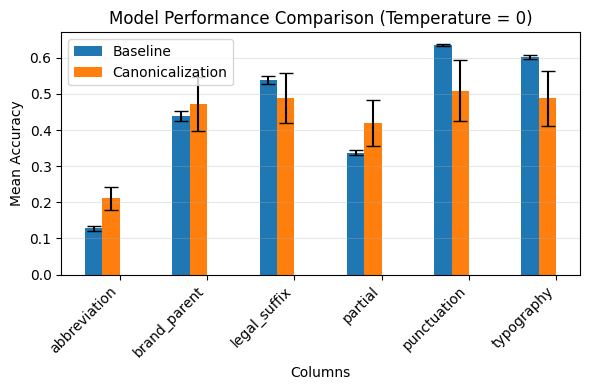

In [13]:
data = pd.read_csv("selected_data2.csv")
baseline_model = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.csv"))/data.groupby("type").size()
canonical_model = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.csv"))/data.groupby("type").size()

# Combine all data and calculate means and stds
datasets = [baseline_model, canonical_model]
dataset_labels = ['Baseline', 'Canonicalization']
columns = baseline_model.columns

# Calculate means and stds for each dataset
means = [df.mean() for df in datasets]
stds = [df.std() for df in datasets]

# Create bar plot
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(columns))
width = 0.2

for i, (mean, std, label) in enumerate(zip(means, stds, dataset_labels)):
    mean_aligned = mean.reindex(columns)
    std_aligned = std.reindex(columns)

    ax.bar(
        x + i * width,
        mean_aligned.values,
        width,
        label=label,
        yerr=std_aligned.values,
        capsize=5
    )

ax.set_xlabel('Columns')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Model Performance Comparison (Temperature = 0)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(columns, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
non_canonical_count_baseline = [753, 756, 751, 754, 753, 752, 752, 760, 762, 750]
non_canonical_count_canonical = [658, 606, 857, 861, 904, 857, 758, 712, 857, 858]

baseline_mean = np.mean(non_canonical_count_baseline)
baseline_std = np.std(non_canonical_count_baseline)

canonical_mean = np.mean(non_canonical_count_canonical)
canonical_std = np.std(non_canonical_count_canonical)

print(f"Baseline -> mean: {baseline_mean:.2f}, std: {baseline_std:.2f}")
print(f"Canonical -> mean: {canonical_mean:.2f}, std: {canonical_std:.2f}")

Baseline -> mean: 754.30, std: 3.72
Canonical -> mean: 792.80, std: 97.18


#### Temperature = 0.3

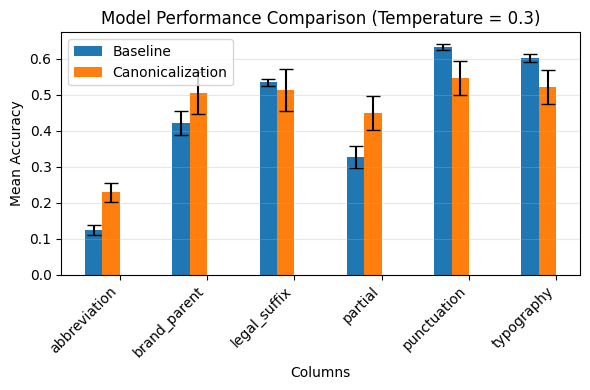

In [15]:
data = pd.read_csv("selected_data2.csv")
baseline_model = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.3.csv"))/data.groupby("type").size()
canonical_model = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.3.csv"))/data.groupby("type").size()

# Combine all data and calculate means and stds
datasets = [baseline_model, canonical_model]
dataset_labels = ['Baseline', 'Canonicalization']
columns = baseline_model.columns

# Calculate means and stds for each dataset
means = [df.mean() for df in datasets]
stds = [df.std() for df in datasets]

# Create bar plot
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(columns))
width = 0.2

for i, (mean, std, label) in enumerate(zip(means, stds, dataset_labels)):
    mean_aligned = mean.reindex(columns)
    std_aligned = std.reindex(columns)

    ax.bar(
        x + i * width,
        mean_aligned.values,
        width,
        label=label,
        yerr=std_aligned.values,
        capsize=5
    )

ax.set_xlabel('Columns')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Model Performance Comparison (Temperature = 0.3)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(columns, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Vanilla model vs canonicalization

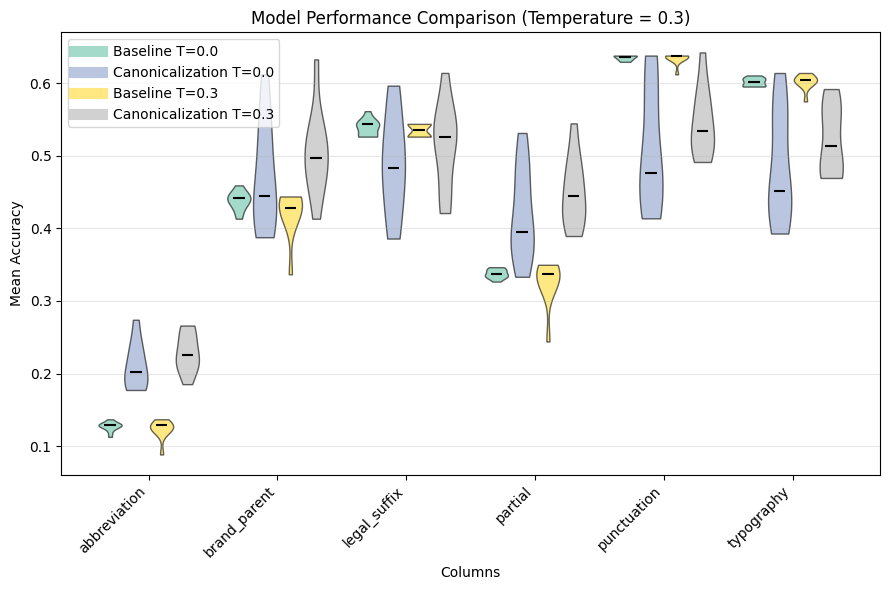

,std_abbreviation,std_brand_parent,std_legal_suffix,std_partial,std_punctuation,std_typography
Baseline T=0.0,0.006361,0.013052,0.011841,0.006233,0.003549,0.005826
Canonicalization T=0.0,0.031682,0.074483,0.069416,0.063312,0.083493,0.076592
Baseline T=0.3,0.013197,0.032554,0.009246,0.030952,0.007987,0.010786
Canonicalization T=0.3,0.026666,0.058311,0.059090,0.047806,0.046858,0.047813


In [16]:
data = pd.read_csv("selected_data2.csv")
baseline_model_t00 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.csv"))/data.groupby("type").size()
canonical_model_t00 = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.csv"))/data.groupby("type").size()
baseline_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.3.csv"))/data.groupby("type").size()
canonical_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.3.csv"))/data.groupby("type").size()

# Combine all data and calculate means and stds
datasets = [baseline_model_t00, canonical_model_t00, baseline_model_t03, canonical_model_t03]
dataset_labels = ['Baseline T=0.0', 'Canonicalization T=0.0', 'Baseline T=0.3', 'Canonicalization T=0.3']
columns = baseline_model_t00.columns

# Calculate means and stds for each dataset
means = [df.mean() for df in datasets]
stds = [df.std() for df in datasets]

# Create bar plot
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(columns))
width = 0.2

colors = plt.cm.Set2(np.linspace(0, 1, len(datasets)))

for i, (df, label, color) in enumerate(zip(datasets, dataset_labels, colors)):
    data_by_col = [df[col].dropna().values for col in columns]
    positions = x + i * width

    parts = ax.violinplot(
        data_by_col,
        positions=positions,
        widths=width * 0.9,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    for body in parts["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.6)

    parts["cmedians"].set_color("black")
    ax.plot([], [], color=color, linewidth=8, alpha=0.6, label=label)

ax.set_xlabel('Columns')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Model Performance Comparison (Temperature = 0.3)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(columns, rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


stats_2d = np.array([
    np.r_[d.std().reindex(columns).values]
    for d in datasets
])

stat_columns = [f"std_{c}" for c in columns]
stats_df = pd.DataFrame(stats_2d, index=dataset_labels, columns=stat_columns)

display(stats_df)


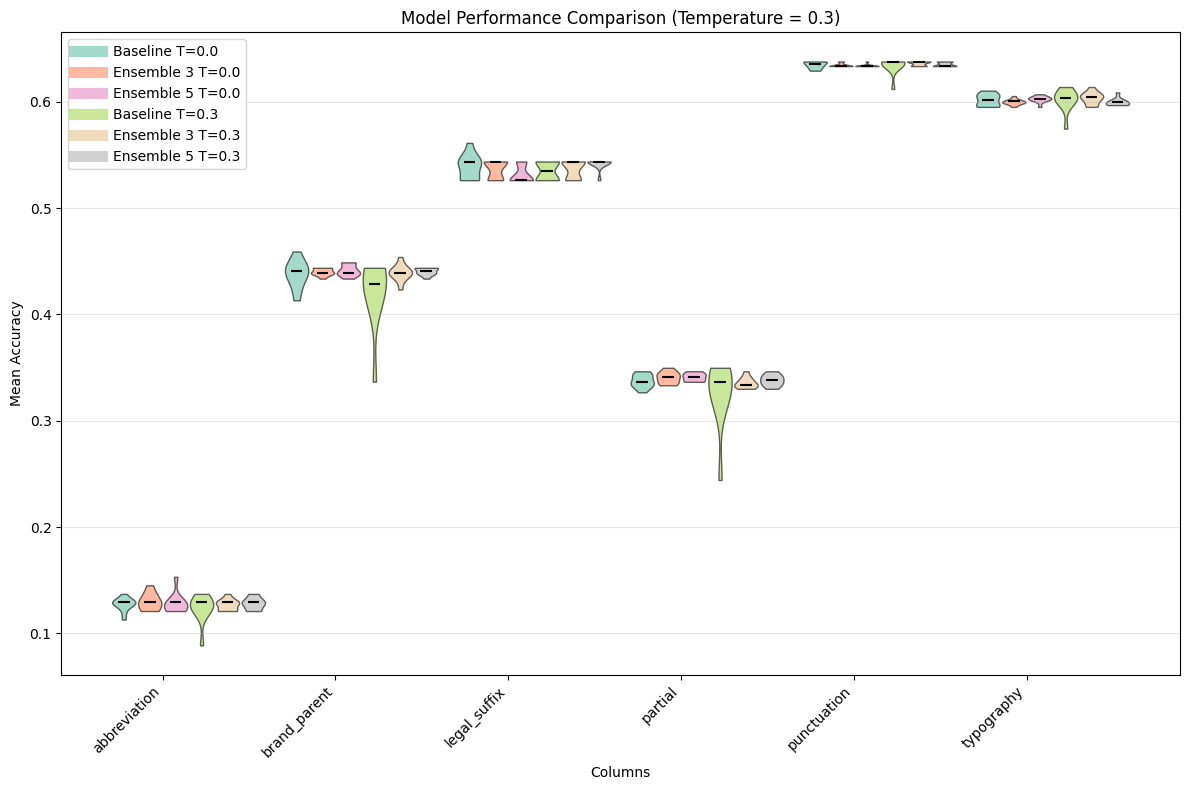

In [17]:
data = pd.read_csv("selected_data2.csv")
baseline_model_t00 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.csv"))/data.groupby("type").size()
e3_model_t00 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.csv"))/data.groupby("type").size()
e5_model_t00 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_5_t0.csv"))/data.groupby("type").size()
baseline_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.3.csv"))/data.groupby("type").size()
e3_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.3.csv"))/data.groupby("type").size()
e5_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_5_t0.3.csv"))/data.groupby("type").size()

# Combine all data and calculate means and stds
datasets = [baseline_model_t00, e3_model_t00, e5_model_t00, baseline_model_t03, e3_model_t03, e5_model_t03]
dataset_labels = ['Baseline T=0.0', 'Ensemble 3 T=0.0', 'Ensemble 5 T=0.0', 'Baseline T=0.3', 'Ensemble 3 T=0.3', 'Ensemble 5 T=0.3']
columns = baseline_model_t00.columns

# Calculate means and stds for each dataset
means = [df.mean() for df in datasets]
stds = [df.std() for df in datasets]

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(columns))
width = 0.15

for i, (mean, std, label) in enumerate(zip(means, stds, dataset_labels)):
    mean_aligned = mean.reindex(columns)
    # std_aligned = std.reindex(columns)

    data_by_col = [datasets[i][col].dropna().values for col in columns]
    positions = x + i * width
    color = plt.cm.Set2(i / max(1, len(datasets) - 1))

    parts = ax.violinplot(
        data_by_col,
        positions=positions,
        widths=width * 0.9,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    for body in parts["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.6)

    parts["cmedians"].set_color("black")
    ax.plot([], [], color=color, linewidth=8, alpha=0.6, label=label)

ax.set_xlabel('Columns')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Model Performance Comparison (Temperature = 0.3)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(columns, rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Vanilla model vs prompt ensembling

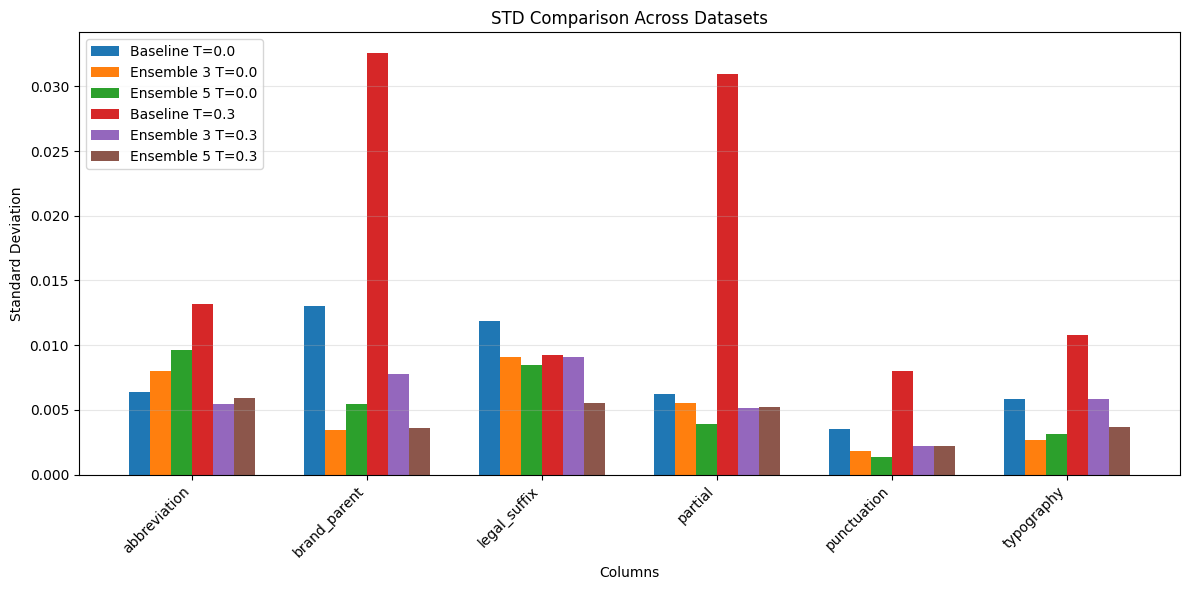

In [18]:
# Use existing datasets, dataset_labels, and columns
stds = [df.std().reindex(columns) for df in datasets]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(columns))
width = 0.12  # 6 datasets -> compact grouped bars

for i, (std, label) in enumerate(zip(stds, dataset_labels)):
    ax.bar(
        x + i * width,
        std.values,
        width=width,
        label=label
    )

ax.set_xlabel("Columns")
ax.set_ylabel("Standard Deviation")
ax.set_title("STD Comparison Across Datasets")
ax.set_xticks(x + width * (len(datasets) - 1) / 2)
ax.set_xticklabels(columns, rotation=45, ha="right")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


#### Different techniques for Temperature = 0.3

In [19]:
data = pd.read_csv("selected_data2.csv")
baseline_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.3.csv"))/data.groupby("type").size()
e3_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.3.csv"))/data.groupby("type").size()
canonical_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.3.csv"))/data.groupby("type").size()
e3_canonical_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_canonicalization_t0.3.csv"))/data.groupby("type").size()

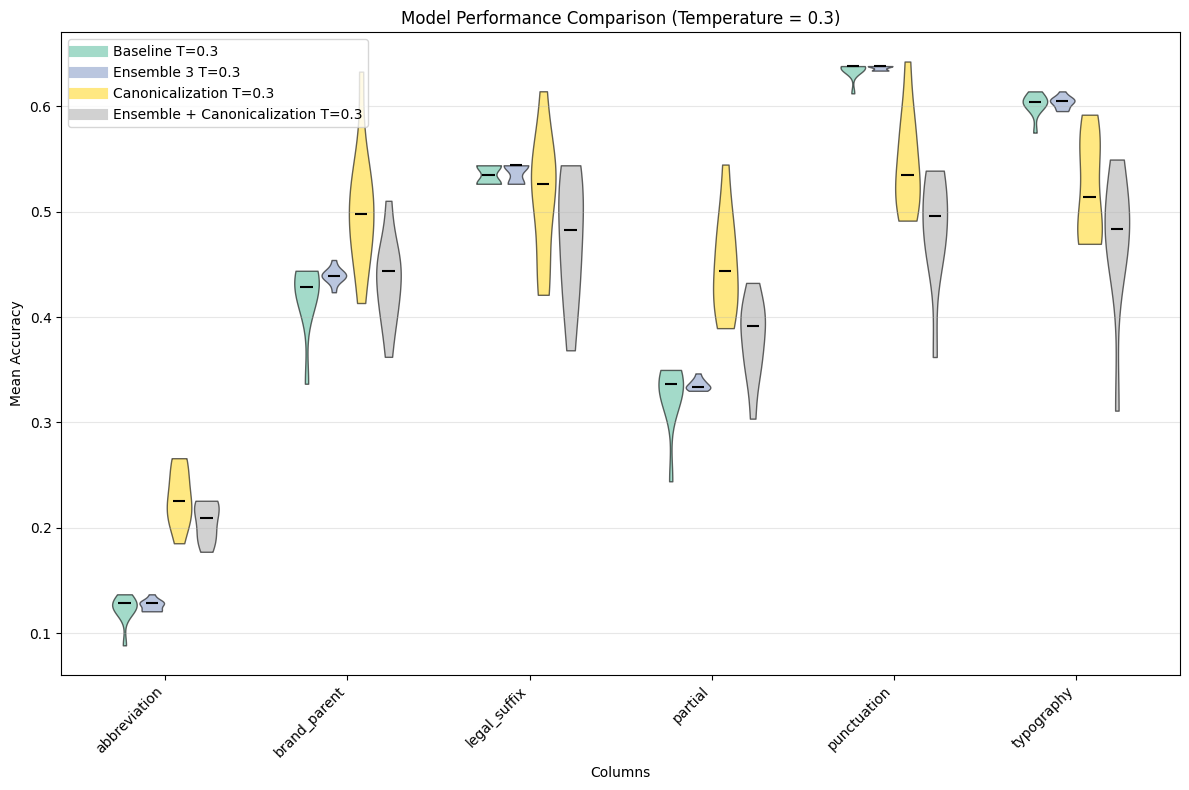

In [20]:
data = pd.read_csv("selected_data2.csv")
baseline_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "base_model_t0.3.csv"))/data.groupby("type").size()
e3_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_3_t0.3.csv"))/data.groupby("type").size()
canonical_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "canonical_t0.3.csv"))/data.groupby("type").size()
e3_canonical_model_t03 = pd.read_csv(os.path.join(os.getcwd(), "results", "ensemble_canonicalization_t0.3.csv"))/data.groupby("type").size()

# Combine all data and calculate means and stds
datasets = [baseline_model_t03, e3_model_t03, canonical_model_t03, e3_canonical_model_t03]
dataset_labels = ['Baseline T=0.3', 'Ensemble 3 T=0.3', 'Canonicalization T=0.3', 'Ensemble + Canonicalization T=0.3']
columns = baseline_model_t03.columns

# Calculate means and stds for each dataset
means = [df.mean() for df in datasets]
stds = [df.std() for df in datasets]

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(columns))
width = 0.15

colors = plt.cm.Set2(np.linspace(0, 1, len(datasets)))

for i, (df, label, color) in enumerate(zip(datasets, dataset_labels, colors)):
    data_by_col = [df[col].dropna().values for col in columns]
    positions = x + i * width

    parts = ax.violinplot(
        data_by_col,
        positions=positions,
        widths=width * 0.9,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    for body in parts["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.6)

    parts["cmedians"].set_color("black")
    ax.plot([], [], color=color, linewidth=8, alpha=0.6, label=label)

ax.set_xlabel('Columns')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Model Performance Comparison (Temperature = 0.3)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(columns, rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()